*Machine Learning* is made up to two words ie * Machine * and *Learning*  . 
In context of computation machine is just a fancy word for a function .
A function is mathematically a relationship between a domain of value and their possible co-domain (range) of value.

For example :

f(x)=x^2 

input : x is any natural number (domain)

f(x)-> machine (function)

x^2 is the calculations that machine does ie , produce the square of the input.

But not all machines know what to compute. They must be taugh how and what values need to be added/multiplied  together and so on to produce the desired output. 

We will start with a very simple ML algo called Linear Regression and then move on to more complex algo all the way to tranformers. Buckle up and get you env ready.

## Prerequisite: 
Pre University Mathematics is a must specially basic understanding of probability , multivariable calculus and linear algebra.

Python Libs: Numpy Pandas are prerequisite.



# Ready ?

Lets first define what kind of machine we are going to build .
## Problem Statement .

The Scenario: Predicting House PricesImagine you are a real estate agent trying to build an automated tool to estimate how much a house will sell for based on its main features. 
Input 1 (x1): Size of the house in square feet.
Input 2 (x2): Number of bedrooms.
Output (y): Price of the house in thousands of dollars.

You find in you database that there are hundres of informations regarding the prices from previous transactions. You want a machine that make you work easy ie tell you the most reasonable price given square footage and number of bedrooms.

Lets first simulate the database of previous transactions .

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   X1_size      500 non-null    int32  
 1   X2_bedrooms  500 non-null    int32  
 2   Y_price      500 non-null    float64
dtypes: float64(1), int32(2)
memory usage: 7.9 KB
None
           X1_size  X2_bedrooms       Y_price
count   500.000000   500.000000    500.000000
mean   1923.574000     2.954000  38666.208731
std     600.488322     1.433874  12017.478005
min     801.000000     1.000000  16129.396968
25%    1439.750000     2.000000  29000.262889
50%    1939.500000     3.000000  39018.715536
75%    2439.250000     4.000000  49185.466010
max    2999.000000     5.000000  60198.341425


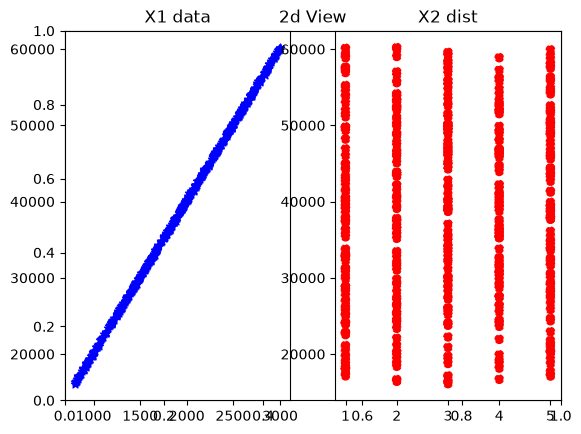

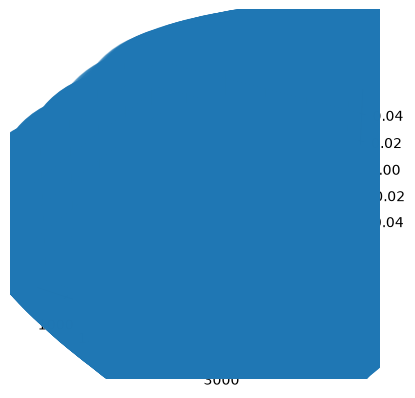

In [30]:

# Generate training data of previous records to train our machine.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

X1=np.random.randint(800,3000,size=500) #square footage
X2=np.random.randint(1,6,size=500) #bedroooms 

# 2. Add random Gaussian noise (Mean=0, Standard Deviation=15)
# This prevents the data from being a mathematically "perfect" line
noise = np.random.normal(0,100,size=500)

Y=20*X1 + 50*X2 + noise +40

# Lets analyse the data  ie how it looks
df=pd.DataFrame({
    "X1_size":X1,
    "X2_bedrooms":X2,
    "Y_price":Y
})

print(df.info())
print(df.describe())

# Graphs analysis 2d 

plt.title("2d View")
plt.subplot(1,2,1)
plt.title("X1 data")
plt.scatter(X1,Y, marker="*",color="blue")

plt.subplot(1,2,2)
plt.scatter(X2,Y,marker="o",linestyle="--",color="red")
plt.title("X2 dist")

plt.show()


#Graph analysis 3d 
plt.axes(projection="3d")
plt.scatter(X1,X2,Y)
plt.show()







The graphical analysis says there is lot of linearity in  our data. We can approximate this with some linear relation such as 

ypred =w1x1+w2x2+b

Y=WX+b (matrix notation)

We have to write a algo that does something like that. 

One way is to put x1 x2 value in this equation with w1, w2 (weights ) and b( bias) as randomly initialised and try to calculate how accurate the prediction are and then change the values of weights and biases to get even better prediction that the previous one and continue this process untill we have fairly well mode.

So our objective function will be :

Objective =Sigma (ypred-y)^2 : we have to minimize this loss ie deviation from real value of y.
Since this is a parabola like it convex and it has exatly one minimum which is at its saddle point ie where derivative are zero  or we can get the minimum error weights and biases via gradient descent too. there are many libraries that implement this such as scikit-learn.

In [31]:
from sklearn.model_selection import train_test_split
# prepare data for training 

X=np.column_stack((X1,X2))
# tranin test split
x_train,x_test,y_train ,y_test=train_test_split(X,Y,test_size=.2,random_state=42)


In [ ]:
#train
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[20. ,51.53]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,34.44
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[12120.74, 28.51]"


In [35]:
#testing
y_pred=model.predict(x_test)

from sklearn.metrics import mean_absolute_error , root_mean_squared_error,r2_score

print("MAE ", mean_absolute_error(y_test,y_pred))
print("RMSE ", root_mean_squared_error(y_test,y_pred))
print("R2 score ", r2_score(y_test,y_pred))

new_house=np.array([[1000,4]])
price= model.predict(new_house)

print(price)

MAE  87.51665782213935
RMSE  109.30809428998171
R2 score  0.9999096465216293
[20243.76664682]


In [ ]:
#save model

import pickle
with open("linear_model_weight.pkl","wb") as file:
    pickle.dump(model,file)

In [38]:
#use model back

with open("linear_model_weight.pkl","rb") as file:
    model=pickle.load(file)
print(model.predict(np.array([[1000,4]])))

[20243.76664682]
